In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pylab as plt
import seaborn as sns


---
# 1. Análisis del DataFrame

---
## Lectura del dataset

In [45]:
url = 'https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv'

df = pd.read_csv(url)

print('Shape del dataset:', df.shape)
df.head()

Shape del dataset: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


2. Entender  el estado de los datos, para ello puedo emplear los comandos básicos del pandas

Tipos de datos, columnas y memoria


In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


Estadísticas descriptivas de todas las columnas numéricas


In [47]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


Conteo de valores nulos por columna


In [48]:
# isnull() e isna() son equivalentes
print('Nulos con isnull():')
print(df.isnull().sum())
print('\nNulos con isna():')
print(df.isna().sum())

Nulos con isnull():
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Nulos con isna():
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


3. Número de variables del dataset y tipo

In [49]:
print(f'Número total de variables (columnas): {df.shape[1]}')
print(f'Número total de observaciones (filas): {df.shape[0]}')
print('\nTipo de cada variable:')
print(df.dtypes)
print('\nResumen por tipo:')
print(df.dtypes.value_counts())



Número total de variables (columnas): 10
Número total de observaciones (filas): 20640

Tipo de cada variable:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

Resumen por tipo:
float64    9
str        1
Name: count, dtype: int64


Conclusión:
- 9 variables numéricas (float64 / int64)
- 1 variable categórica (object): ocean_proximity

4. ¿Existen valores faltantes? ¿En qué variables y cuántos?

In [50]:
nulos = df.isnull().sum()
nulos_pct = (df.isnull().sum() / len(df)) * 100

resumen_nulos = pd.DataFrame({
    'Cantidad de nulos': nulos,
    'Porcentaje (%)': nulos_pct.round(2)
})

print('Variables con valores faltantes:')
print(resumen_nulos[resumen_nulos['Cantidad de nulos'] > 0])



Variables con valores faltantes:
                Cantidad de nulos  Porcentaje (%)
total_bedrooms                207             1.0


Conclusión:
- total_bedrooms tiene ~207 valores nulos (~1% del dataset)

5. Elementos únicos en la columna `ocean_proximity`

In [51]:
print('Valores únicos en ocean_proximity:')
print(df['ocean_proximity'].unique())

print('\nConteo de cada categoría:')
print(df['ocean_proximity'].value_counts())

Valores únicos en ocean_proximity:
<StringArray>
['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND']
Length: 5, dtype: str

Conteo de cada categoría:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


6. Promedio de columnas agrupado por `ocean_proximity` con groupby

In [52]:
cols = ['housing_median_age', 'total_rooms', 'total_bedrooms',
        'population', 'households', 'median_income', 'median_house_value']

# Promedio de cada columna por categoría de ocean_proximity
promedios = df.groupby('ocean_proximity')[cols].mean().round(2)
print('Promedio por categoría de ocean_proximity:')
promedios

Promedio por categoría de ocean_proximity:


,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
ocean_proximity,,,,,,,
<1H OCEAN,29.28,2628.34,546.54,1520.29,517.74,4.23,240084.29
INLAND,24.27,2717.74,533.88,1391.05,477.45,3.21,124805.39
ISLAND,42.40,1574.60,420.40,668.00,276.60,2.74,380440.00
NEAR BAY,37.73,2493.59,514.18,1230.32,488.62,4.17,259212.31
NEAR OCEAN,29.35,2583.70,538.62,1354.01,501.24,4.01,249433.98


Visualización de promedios en un heatmap para realizar una comparación rápida

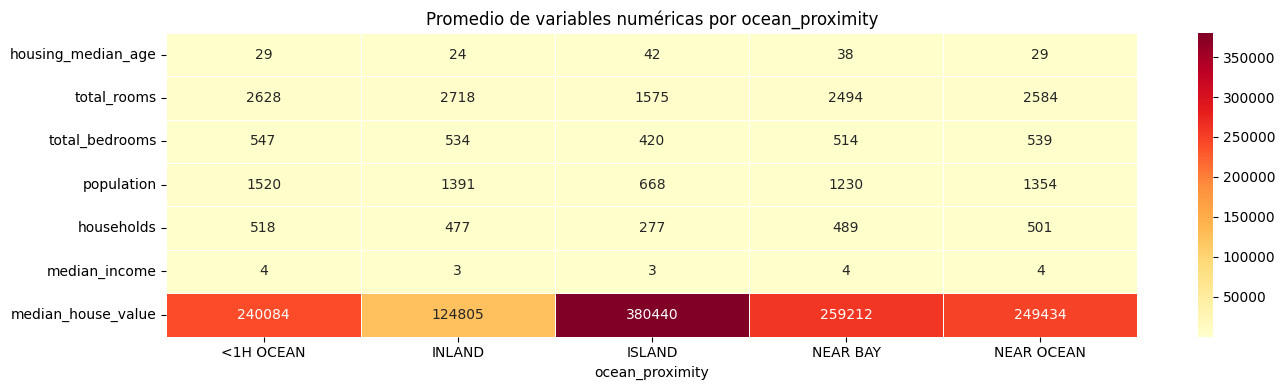

In [53]:
plt.figure(figsize=(14, 4))
sns.heatmap(
    promedios.T,
    annot=True, fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5
)
plt.title('Promedio de variables numéricas por ocean_proximity')
plt.tight_layout()
plt.show()

7. Histograma para cada columna con seaborn

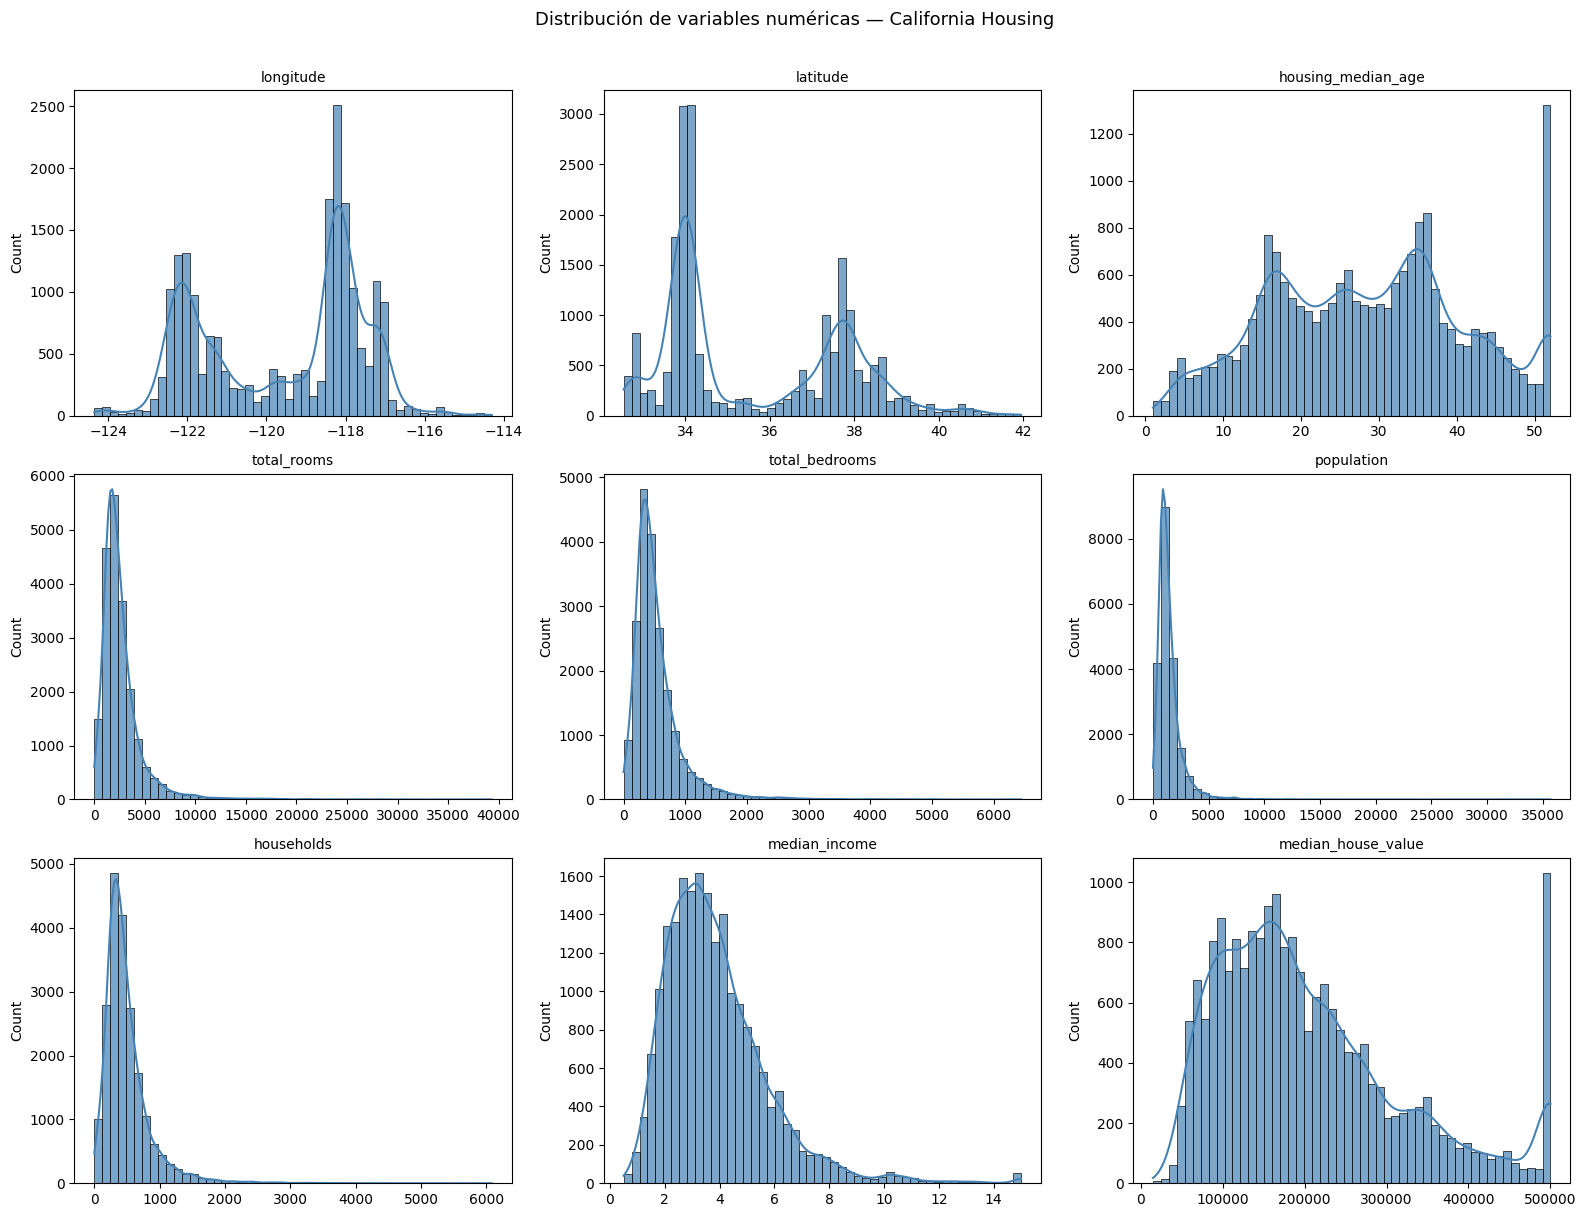

In [54]:
cols_num = df.select_dtypes(include='number').columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cols_num):
    sns.histplot(df[col].dropna(), bins=50, kde=True,
                 ax=axes[i], color='steelblue', alpha=0.7)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

# Ocultar ejes sobrantes si los hay
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables numéricas — California Housing', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Nota: median_house_value muestra un techo en 500,000 USD (los valores iguales o superiores fueron truncados en el censo)

8.  Diagrama de caja (boxplot) de `median_house_value` por `ocean_proximity`

**Recordatorio de la teoría del laboratorio:**
- Q1: 25% de los datos (bigote inferior → caja)
- Q2: mediana (línea dentro de la caja)
- Q3: 75% de los datos (caja → bigote superior)
- IQR = Q3 − Q1
- Outliers: valores fuera de [Q1 − 1.5·IQR, Q3 + 1.5·IQR]

**Ejemplo del laboratorio:**

N = 24
T ordenado: [52 57 57 58 63 66 66 67 67 68 69 70 70 70 70 72 73 75 75 76 76 78 79 89]
N/4 = 6.0

Q1=66.0  Q3=75.0  IQR=9.0
Límite superior (lab): 88.5
Límite inferior (lab): 52.5


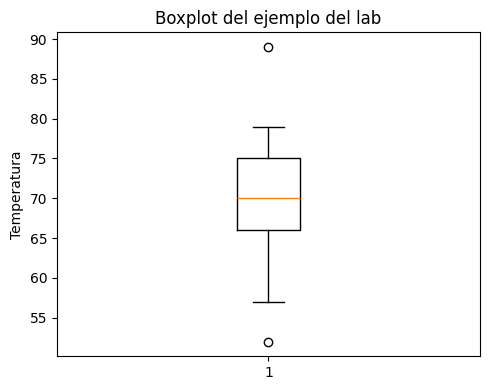

In [55]:
# Ejemplo de cálculo manual de cuartiles e IQR (del lab)
T = np.array([52, 57, 57, 58, 63, 66, 66, 67, 67, 68,
              69, 70, 70, 70, 70, 72, 73, 75, 75, 76, 76, 78, 79, 89])
Tsort = np.sort(T)
print(f'N = {len(T)}')
print(f'T ordenado: {Tsort}')
print(f'N/4 = {len(T)/4}')

Q1 = np.percentile(T, 25)
Q3 = np.percentile(T, 75)
IQR = Q3 - Q1
print(f'\nQ1={Q1}  Q3={Q3}  IQR={IQR}')

IQR_lab = 9   # valor del lab
max_ = 75 + 1.5 * IQR_lab
min_ = 66 - 1.5 * IQR_lab
print(f'Límite superior (lab): {max_}')
print(f'Límite inferior (lab): {min_}')

plt.figure(figsize=(5, 4))
plt.boxplot(T)
plt.title('Boxplot del ejemplo del lab')
plt.ylabel('Temperatura')
plt.tight_layout()
plt.show()

8. Boxplot del dataset de viviendas (código exacto del laboratorio)


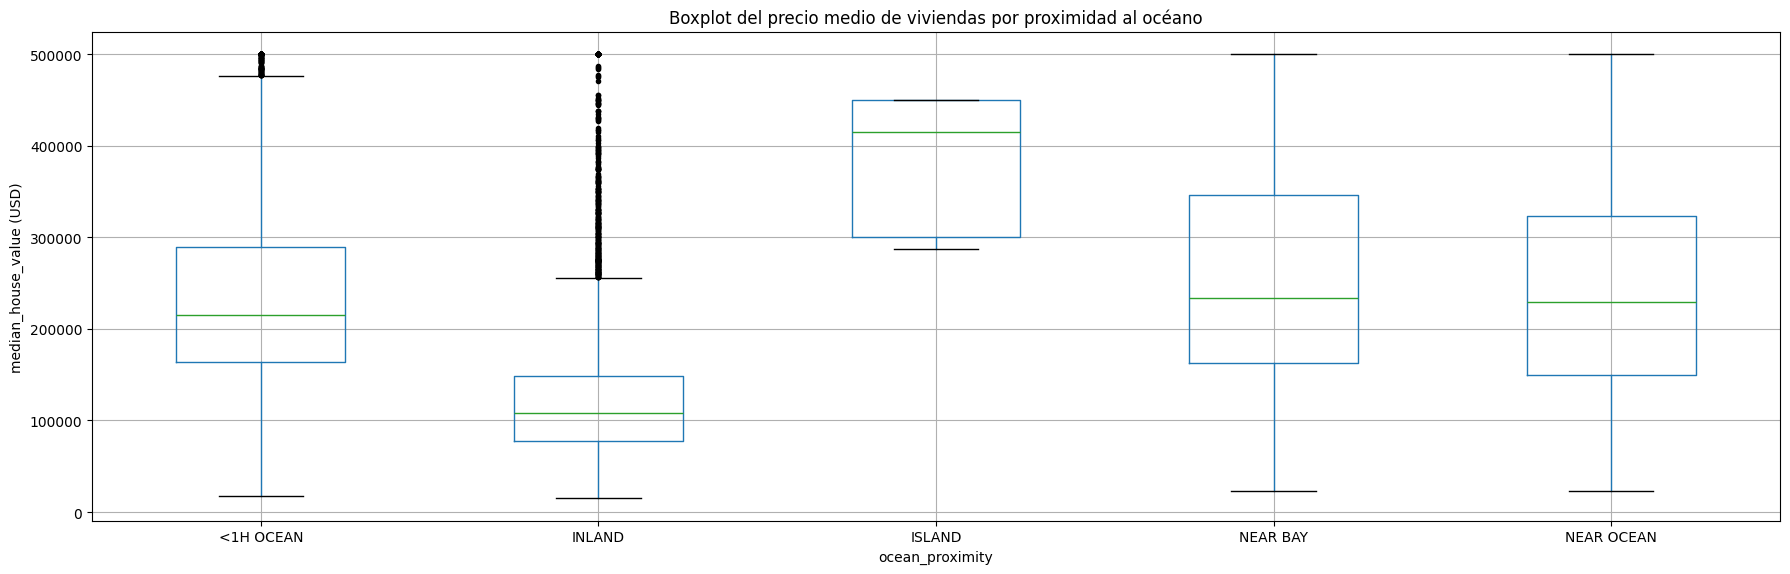

In [56]:
df.boxplot(column='median_house_value', by='ocean_proximity', sym='k.', figsize=(18, 6))
plt.title('Boxplot del precio medio de viviendas por proximidad al océano')
plt.suptitle('')   # eliminar el título automático de pandas
plt.xlabel('ocean_proximity')
plt.ylabel('median_house_value (USD)')
plt.tight_layout()
plt.show()

# Interpretación esperada:
# - ISLAND tiene los precios más altos y mayor dispersión
# - INLAND tiene los precios más bajos
# - <1H OCEAN y NEAR BAY son similares y más altos que INLAND

9. Matriz de correlación con `corr()` y `heatmap()`

In [57]:
# Calcular matriz de correlación (solo columnas numéricas)
corr_matrix = df.select_dtypes(include='number').corr()
print('Correlaciones con median_house_value (ordenadas):')
print(corr_matrix['median_house_value'].sort_values(ascending=False).round(3))

Correlaciones con median_house_value (ordenadas):
median_house_value    1.000
median_income         0.688
total_rooms           0.134
housing_median_age    0.106
households            0.066
total_bedrooms        0.050
population           -0.025
longitude            -0.046
latitude             -0.144
Name: median_house_value, dtype: float64


Heatmap de la matriz de correlación (código del laboratorio)


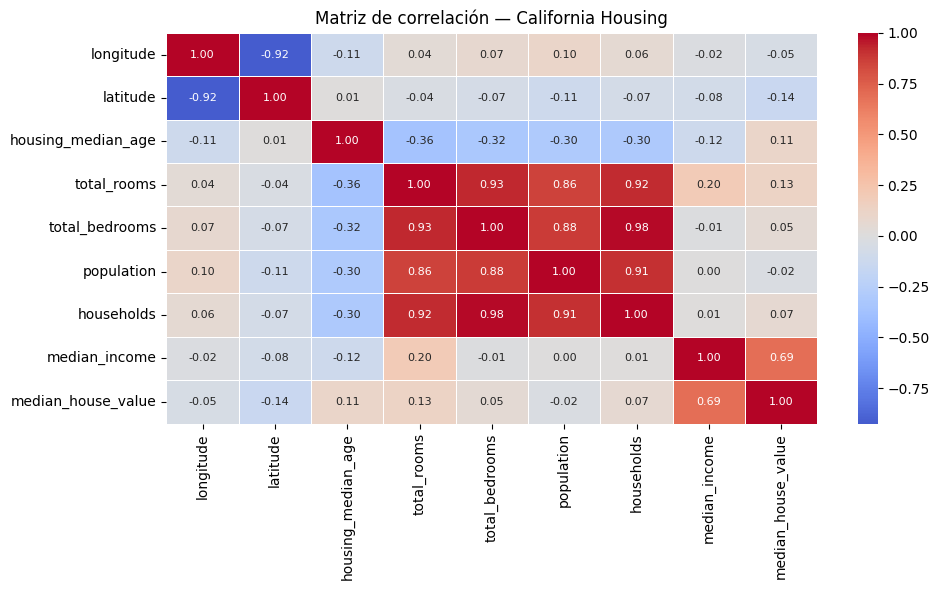

In [58]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            linewidths=0.4, annot_kws={'size': 8})
plt.title('Matriz de correlación — California Housing')
plt.tight_layout()
plt.show()

**Conclusión:**
- median_income es la variable más correlacionada con median_house_value (r~0.69)
- total_rooms y households tienen alta correlación entre sí (multicolinealidad)

10. Pairplot de columnas seleccionadas con seaborn

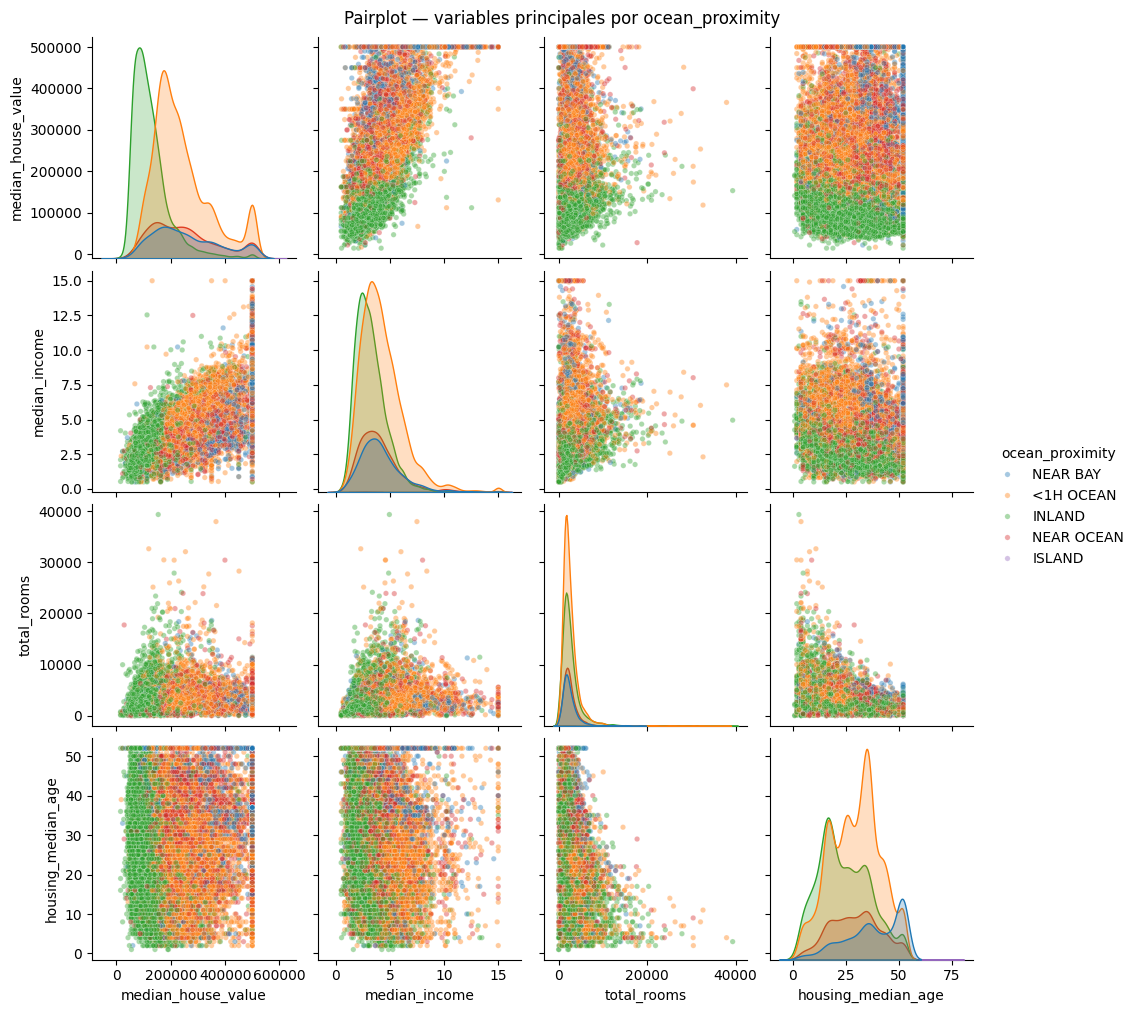

In [59]:
# Columnas exactas del laboratorio
cols_pair = ['median_house_value', 'median_income', 'total_rooms', 'housing_median_age']

# Pairplot coloreado por ocean_proximity
sns.pairplot(
    df[cols_pair + ['ocean_proximity']].dropna(),
    hue='ocean_proximity',
    diag_kind='kde',
    plot_kws={'alpha': 0.4, 's': 15}
)
plt.suptitle('Pairplot — variables principales por ocean_proximity', y=1.01)
plt.show()

11. Scatter plot geográfico coloreado por `median_house_value`

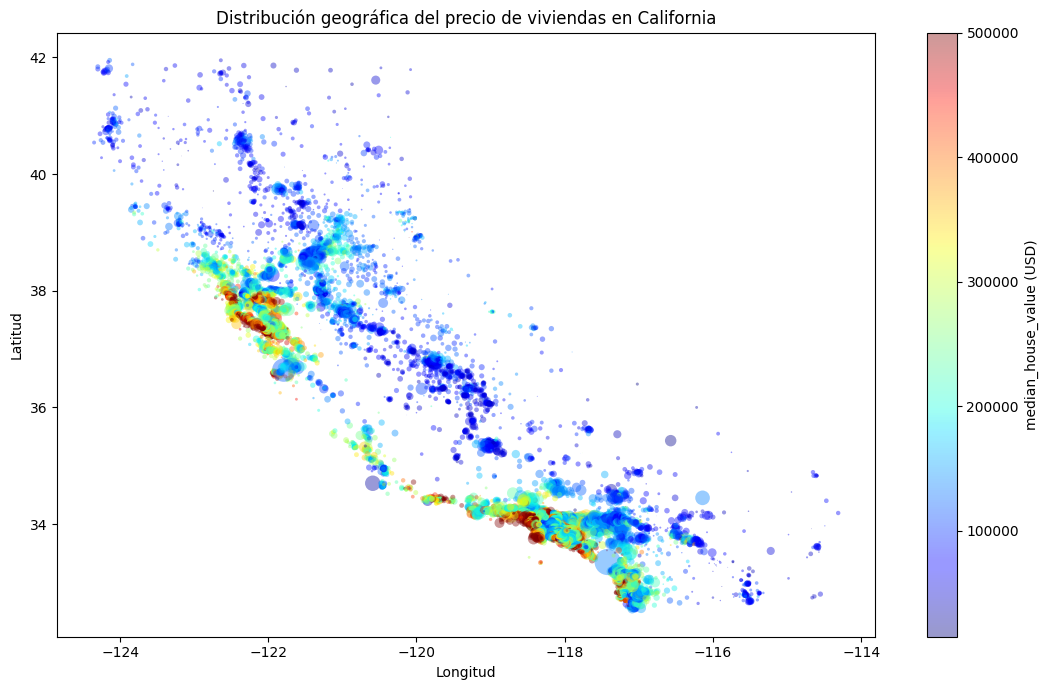

In [60]:
# Scatter plot con seaborn: longitud vs latitud, color = precio
plt.figure(figsize=(11, 7))
scatter = plt.scatter(
    df['longitude'], df['latitude'],
    c=df['median_house_value'],
    cmap='jet',
    alpha=0.4,
    s=df['population'] / 100,   # tamaño del punto = población relativa
    edgecolors='none'
)
plt.colorbar(scatter, label='median_house_value (USD)')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.title('Distribución geográfica del precio de viviendas en California')
plt.tight_layout()
plt.show()

**Conclusión:**
- Los precios más altos (rojo) se concentran en la costa: San Francisco y Los Ángeles
- El interior (azul) tiene precios mucho más bajos

---
# 2.0 Preparación del DataFrame

---
12. División inicial train/test y análisis del sampling bias

**Pregunta del laboratorio:** ¿Es significativa la muestra que se está considerando?

Una división aleatoria simple puede generar sesgo si el dataset no es homogéneo. La solución es el **muestreo estratificado**.

In [61]:
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit

# División aleatoria simple (código del laboratorio)
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)
print(f'Train aleatorio: {len(train_set)} muestras')
print(f'Test aleatorio:  {len(test_set)} muestras')

Train aleatorio: 16512 muestras
Test aleatorio:  4128 muestras


13. Crear categoría de ingreso para el muestreo estratificado (código del laboratorio)

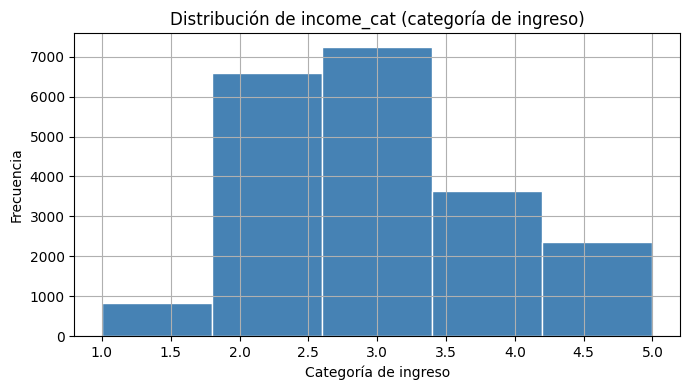

In [62]:
df['income_cat'] = pd.cut(
    df['median_income'],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5]
)

plt.figure(figsize=(7, 4))
df['income_cat'].hist(bins=5, color='steelblue', edgecolor='white')
plt.title('Distribución de income_cat (categoría de ingreso)')
plt.xlabel('Categoría de ingreso')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Muestreo estratificado por income_cat (código del laboratorio)


In [63]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df, df['income_cat']):
    strat_train_set = df.loc[train_index]
    strat_test_set  = df.loc[test_index]

print(f'Train estratificado: {len(strat_train_set)} muestras')
print(f'Test  estratificado: {len(strat_test_set)} muestras')

Train estratificado: 16512 muestras
Test  estratificado: 4128 muestras


Comparar proporciones: Overall vs Estratificado vs Aleatorio (código del laboratorio)


In [64]:
def income_cat_proportions(data):
    return data['income_cat'].value_counts() / len(data)

train_set_r2, test_set_r2 = train_test_split(df, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    'Overall'   : income_cat_proportions(df),
    'Stratified': income_cat_proportions(strat_test_set),
    'Random'    : income_cat_proportions(test_set_r2),
}).sort_index()

compare_props['Rand. %error']  = abs(100 * compare_props['Random']     / compare_props['Overall'] - 100)
compare_props['Strat. %error'] = abs(100 * compare_props['Stratified'] / compare_props['Overall'] - 100)

print('Comparación de proporciones por income_cat:')
print(compare_props.round(4))



Comparación de proporciones por income_cat:
            Overall  Stratified  Random  Rand. %error  Strat. %error
income_cat                                                          
1            0.0398      0.0400  0.0402        0.9732         0.3650
2            0.3188      0.3188  0.3244        1.7323         0.0152
3            0.3506      0.3505  0.3585        2.2664         0.0138
4            0.1763      0.1764  0.1674        5.0563         0.0275
5            0.1144      0.1143  0.1095        4.3184         0.0847


**Conclusión:**
- El muestreo estratificado tiene errores mucho menores que el aleatorio porque preserva la distribución de ingresos del dataset completo

13. Feature Engineering: crear nuevas variables derivadas

Se crean variables de densidad que son más informativas que los totales absolutos.

In [65]:
# Trabajar con el conjunto de entrenamiento estratificado
# Eliminar columna auxiliar income_cat antes de entrenar
df_train = strat_train_set.drop('income_cat', axis=1).copy()
df_test  = strat_test_set.drop('income_cat', axis=1).copy()

# Crear nuevas variables derivadas (Feature Engineering — código del lab)
df_train['rooms_per_household']      = df_train['total_rooms']    / df_train['households']
df_train['bedrooms_per_room']        = df_train['total_bedrooms'] / df_train['total_rooms']
df_train['population_per_household'] = df_train['population']     / df_train['households']

print('Nuevas variables creadas:')
print(df_train[['rooms_per_household', 'bedrooms_per_room', 'population_per_household']].describe().round(3))

Nuevas variables creadas:
       rooms_per_household  bedrooms_per_room  population_per_household
count            16512.000          16354.000                 16512.000
mean                 5.440              0.213                     3.096
std                  2.612              0.057                    11.585
min                  1.130              0.100                     0.692
25%                  4.442              0.175                     2.431
50%                  5.232              0.203                     2.818
75%                  6.056              0.240                     3.281
max                141.909              1.000                  1243.333


Verificación de la correlación de las nuevas variables con median_house_value


In [66]:
cols_nuevas = ['rooms_per_household', 'bedrooms_per_room',
               'population_per_household', 'median_income', 'median_house_value']

corr_nuevas = df_train[cols_nuevas].corr()
print('Correlación de nuevas variables con median_house_value:')
print(corr_nuevas['median_house_value'].sort_values(ascending=False).round(3))

# bedrooms_per_room suele tener correlación negativa más fuerte que total_bedrooms

Correlación de nuevas variables con median_house_value:
median_house_value          1.000
median_income               0.687
rooms_per_household         0.146
population_per_household   -0.022
bedrooms_per_room          -0.260
Name: median_house_value, dtype: float64


Limpieza de datos — Imputación de valores nulos con `SimpleImputer`

La columna `total_bedrooms` tiene valores nulos. Se rellenan con la media usando `SimpleImputer`.

In [67]:
from sklearn.impute import SimpleImputer

# Verificar nulos en df_train
print('Nulos en df_train antes de imputar:')
print(df_train.isnull().sum())

Nulos en df_train antes de imputar:
longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms              158
population                    0
households                    0
median_income                 0
median_house_value            0
ocean_proximity               0
rooms_per_household           0
bedrooms_per_room           158
population_per_household      0
dtype: int64


In [68]:
# Separar columnas numéricas (excluir ocean_proximity — es categórica)
df_train_num = df_train.drop('ocean_proximity', axis=1)

# Imputar con la media (código del lab)
imp_mean = SimpleImputer(strategy='mean')
imp_mean.fit(df_train_num)

print('Medias calculadas por el imputer:')
for col, val in zip(df_train_num.columns, imp_mean.statistics_):
    print(f'  {col:35s}: {val:.4f}')

Medias calculadas por el imputer:
  longitude                          : -119.5756
  latitude                           : 35.6393
  housing_median_age                 : 28.6534
  total_rooms                        : 2622.5398
  total_bedrooms                     : 534.9146
  population                         : 1419.6874
  households                         : 497.0118
  median_income                      : 3.8759
  median_house_value                 : 207005.3224
  rooms_per_household                : 5.4404
  bedrooms_per_room                  : 0.2129
  population_per_household           : 3.0965


14. Comparar estadísticos del imputer vs mediana del dataset

In [69]:
# Comparar imp_mean.statistics_ con df_train_num.median() (código del laboratorio)
comparacion = pd.DataFrame({
    'Media (imputer)': imp_mean.statistics_,
    'Mediana (df)'   : df_train_num.median().values
}, index=df_train_num.columns)

print('Comparación media vs mediana por columna:')
print(comparacion.round(3))

Comparación media vs mediana por columna:
                          Media (imputer)  Mediana (df)
longitude                        -119.576      -118.510
latitude                           35.639        34.260
housing_median_age                 28.653        29.000
total_rooms                      2622.540      2119.000
total_bedrooms                    534.915       433.000
population                       1419.687      1164.000
households                        497.012       408.000
median_income                       3.876         3.542
median_house_value             207005.322    179500.000
rooms_per_household                 5.440         5.232
bedrooms_per_room                   0.213         0.203
population_per_household            3.096         2.818


**Conclusión:**
- total_rooms, population y total_bedrooms tienen alta asimetría → la media y la mediana difieren bastante para esas variables
- Para distribuciones asimétricas es mejor imputar con la mediana

Construir la matriz de características imputada (código del laboratorio)


In [70]:
X_imp = imp_mean.transform(df_train_num)
housing_tr = pd.DataFrame(X_imp, columns=df_train_num.columns)

print('Nulos después de imputar:')
print(housing_tr.isnull().sum())
print('Shape de housing_tr:', housing_tr.shape)

Nulos después de imputar:
longitude                   0
latitude                    0
housing_median_age          0
total_rooms                 0
total_bedrooms              0
population                  0
households                  0
median_income               0
median_house_value          0
rooms_per_household         0
bedrooms_per_room           0
population_per_household    0
dtype: int64
Shape de housing_tr: (16512, 12)


15. Manejo de atributos categóricos con `OneHotEncoder`

**¿Qué hace este código?**  
`OneHotEncoder` transforma la columna `ocean_proximity` (5 categorías) en 5 columnas binarias (0 o 1), una por cada categoría. Esto permite que los modelos numéricos procesen la variable categórica sin asumir un orden entre las categorías.

In [71]:
from sklearn.preprocessing import OneHotEncoder

# Extraer la columna categórica del df de entrenamiento
housing_cat = df_train[['ocean_proximity']]
print('Valores únicos:', df_train['ocean_proximity'].unique())

# Aplicar OneHotEncoder (código del laboratorio)
cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

print('\nPrimeras 5 filas del encoding:')
print(housing_cat_1hot[:5])
print('\nCategorías codificadas:')
print(cat_encoder.categories_)

Valores únicos: <StringArray>
['INLAND', 'NEAR OCEAN', '<1H OCEAN', 'NEAR BAY', 'ISLAND']
Length: 5, dtype: str

Primeras 5 filas del encoding:
[[0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0.]]

Categorías codificadas:
[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
      dtype=object)]


Creación de un DataFrame con las columnas codificadas y unirlo con housing_tr


In [72]:
df_cat_1hot = pd.DataFrame(
    housing_cat_1hot,
    columns=cat_encoder.categories_[0]
)

# Resetear índices para que el join funcione correctamente
housing_tr_reset  = housing_tr.reset_index(drop=True)
df_cat_1hot_reset = df_cat_1hot.reset_index(drop=True)

housing_tr_ = housing_tr_reset.join(df_cat_1hot_reset)

print('Shape después del OneHotEncoding:', housing_tr_.shape)
print('Columnas:')
print(housing_tr_.columns.tolist())
housing_tr_.head(3)

Shape después del OneHotEncoding: (16512, 17)
Columnas:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', '<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,bedrooms_per_room,population_per_household,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,72100.0,5.485836,0.205784,3.168555,0.0,1.0,0.0,0.0,0.0
1,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,279600.0,6.927083,0.160714,2.623698,0.0,0.0,0.0,0.0,1.0
2,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,82700.0,5.393333,0.191595,2.223333,0.0,1.0,0.0,0.0,0.0


16. Escalamiento de variables con `MinMaxScaler`

In [73]:
from sklearn.preprocessing import MinMaxScaler

# Columnas a escalar (código del lab — excluye la variable objetivo)
cols_scale = [
    'longitude', 'latitude', 'housing_median_age', 'total_rooms',
    'total_bedrooms', 'population', 'households', 'median_income',
    '<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'
]

# Agregar columnas de feature engineering si existen
cols_fe = ['rooms_per_household', 'bedrooms_per_room', 'population_per_household']
cols_disponibles = [c for c in cols_scale if c in housing_tr_.columns]

housing_scale = housing_tr_[cols_disponibles]

# Aplicar MinMaxScaler (código del lab)
scaler = MinMaxScaler()
scaler.fit(housing_scale)
X_scaled = scaler.transform(housing_scale)

housing_prepared = pd.DataFrame(X_scaled, columns=housing_scale.columns)

print('Shape del dataset preparado:', housing_prepared.shape)
print('Rango de valores después de escalar (deben ser [0, 1]):')
print(housing_prepared.describe().loc[['min', 'max']].round(3))

Shape del dataset preparado: (16512, 13)
Rango de valores después de escalar (deben ser [0, 1]):
     longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
min        0.0       0.0                 0.0          0.0             0.0   
max        1.0       1.0                 1.0          1.0             1.0   

     population  households  median_income  <1H OCEAN  INLAND  ISLAND  \
min         0.0         0.0            0.0        0.0     0.0     0.0   
max         1.0         1.0            1.0        1.0     1.0     1.0   

     NEAR BAY  NEAR OCEAN  
min       0.0         0.0  
max       1.0         1.0  


17. Pipeline completo: housing_train y housing_test listos para modelar

Se consolida todo el proceso anterior en funciones reutilizables y se generan los dos DataFrames finales.

In [74]:
def preparar_dataset(df_in, imp_fit=None, scaler_fit=None, cat_enc_fit=None, es_train=True):
    """
    Pipeline completo de preparación:
    1. Feature Engineering
    2. Imputación de nulos
    3. OneHotEncoding de ocean_proximity
    4. Escalamiento MinMax
    Retorna: (X_preparado, y_labels, objetos_fit)
    """
    df = df_in.copy()

    # ── Separar variable objetivo ─────────────────────────────────────
    y = df['median_house_value'].values
    df = df.drop('median_house_value', axis=1)

    # ── Feature Engineering ───────────────────────────────────────────
    df['rooms_per_household']      = df['total_rooms']    / df['households']
    df['bedrooms_per_room']        = df['total_bedrooms'] / df['total_rooms']
    df['population_per_household'] = df['population']     / df['households']

    # ── Imputación (solo numéricas) ───────────────────────────────────
    df_num = df.drop('ocean_proximity', axis=1)
    if es_train:
        imp = SimpleImputer(strategy='mean')
        imp.fit(df_num)
    else:
        imp = imp_fit
    X_num = pd.DataFrame(imp.transform(df_num), columns=df_num.columns)

    # ── OneHotEncoding ────────────────────────────────────────────────
    cat = df[['ocean_proximity']].reset_index(drop=True)
    if es_train:
        enc = OneHotEncoder(sparse_output=False)
        enc.fit(cat)
    else:
        enc = cat_enc_fit
    X_cat = pd.DataFrame(enc.transform(cat), columns=enc.categories_[0])

    # ── Unir numérico + categórico ────────────────────────────────────
    X_all = X_num.reset_index(drop=True).join(X_cat.reset_index(drop=True))

    # ── Escalamiento ──────────────────────────────────────────────────
    cols_model = [c for c in X_all.columns]
    if es_train:
        sc = MinMaxScaler()
        sc.fit(X_all[cols_model])
    else:
        sc = scaler_fit
    X_scaled = pd.DataFrame(sc.transform(X_all[cols_model]), columns=cols_model)

    if es_train:
        return X_scaled, y, imp, sc, enc
    else:
        return X_scaled, y


print('Función preparar_dataset definida correctamente')

Función preparar_dataset definida correctamente


In [75]:
# Preparar TRAIN
df_train_clean = strat_train_set.drop('income_cat', axis=1).copy()
df_test_clean  = strat_test_set.drop('income_cat', axis=1).copy()

housing_train_X, y_train, imp_obj, sc_obj, enc_obj = preparar_dataset(
    df_train_clean, es_train=True
)

# Preparar TEST (usando los objetos fit del train — NUNCA re-entrenar con test)
housing_test_X, y_test = preparar_dataset(
    df_test_clean,
    imp_fit=imp_obj, scaler_fit=sc_obj, cat_enc_fit=enc_obj,
    es_train=False
)

print('=== Datasets listos para modelar ===')
print(f'housing_train_X : {housing_train_X.shape}  |  y_train: {y_train.shape}')
print(f'housing_test_X  : {housing_test_X.shape}   |  y_test:  {y_test.shape}')
housing_train_X.head(3)

=== Datasets listos para modelar ===
housing_train_X : (16512, 16)  |  y_train: (16512,)
housing_test_X  : (4128, 16)   |  y_test:  (4128,)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,bedrooms_per_room,population_per_household,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,0.287849,0.635494,0.549020,0.098362,0.128061,0.062614,0.131441,0.115426,0.030938,0.117537,0.001993,0.0,1.0,0.0,0.0,0.0
1,0.709163,0.058448,0.117647,0.135168,0.137403,0.056392,0.143017,0.402574,0.041176,0.067460,0.001554,0.0,0.0,0.0,0.0,1.0
2,0.528884,0.300744,0.843137,0.041003,0.049613,0.018610,0.055639,0.163798,0.030281,0.101772,0.001232,0.0,1.0,0.0,0.0,0.0


Modelado — Regresión lineal y evaluación

Se ajusta un modelo de regresión lineal y se responden las preguntas del laboratorio.

In [76]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Entrenar modelo
lr = LinearRegression()
lr.fit(housing_train_X, y_train)

# Predicciones
y_pred_train = lr.predict(housing_train_X)
y_pred_test  = lr.predict(housing_test_X)

# Métricas
def evaluar(y_real, y_pred, nombre):
    mae  = mean_absolute_error(y_real, y_pred)
    rmse = np.sqrt(mean_squared_error(y_real, y_pred))
    r2   = r2_score(y_real, y_pred)
    print(f'{nombre:10s} -> MAE: {mae:,.0f}  |  RMSE: {rmse:,.0f}  |  R²: {r2:.4f}')

evaluar(y_train, y_pred_train, 'TRAIN')
evaluar(y_test,  y_pred_test,  'TEST')

TRAIN      -> MAE: 49,054  |  RMSE: 68,161  |  R²: 0.6529
TEST       -> MAE: 48,967  |  RMSE: 66,800  |  R²: 0.6576


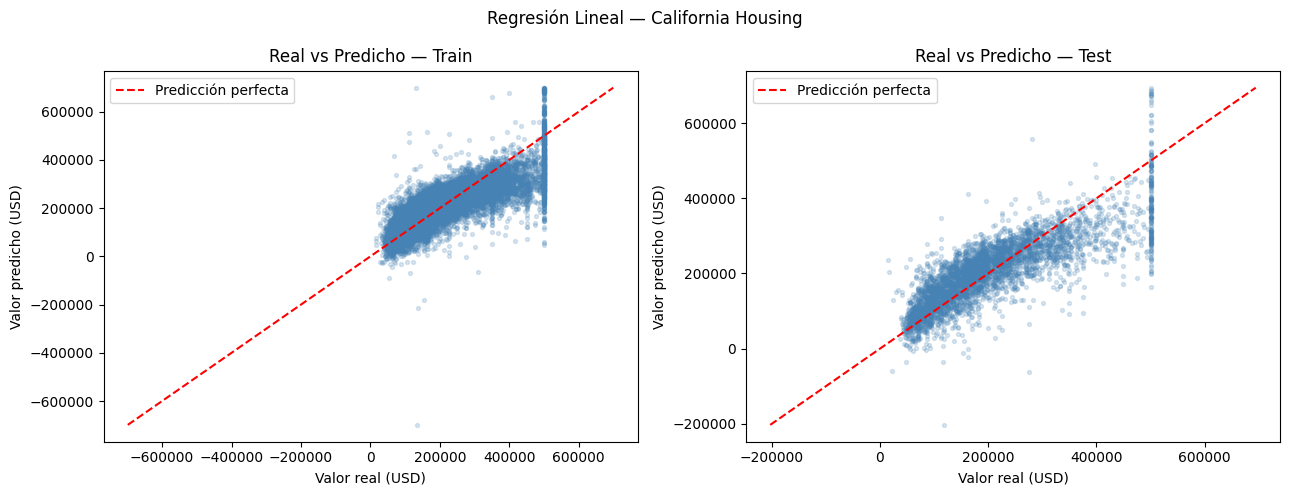

In [77]:
# Gráfico: valores reales vs predicciones
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_real, y_pred, titulo in zip(
    axes,
    [y_train, y_test],
    [y_pred_train, y_pred_test],
    ['Train', 'Test']
):
    ax.scatter(y_real, y_pred, alpha=0.2, s=8, color='steelblue')
    lims = [min(y_real.min(), y_pred.min()), max(y_real.max(), y_pred.max())]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
    ax.set_xlabel('Valor real (USD)')
    ax.set_ylabel('Valor predicho (USD)')
    ax.set_title(f'Real vs Predicho — {titulo}')
    ax.legend()

plt.suptitle('Regresión Lineal — California Housing', fontsize=12)
plt.tight_layout()
plt.show()

**Preguntas finales del laboratorio**

**1. ¿Qué puedes concluir respecto al modelo empleado?**

- El R² en test es moderado (~0.60-0.65). El modelo captura tendencias generales pero tiene errores grandes (RMSE ~60,000-80,000 USD). Hay un techo visible en las predicciones alrededor de 500,000 USD (límite del censo que se propaga a las predicciones).

**2. ¿El modelo de regresión lineal es válido para lo construido?**

- Parcialmente. La relación entre las variables y el precio no es perfectamente lineal (por ejemplo, median_income tiene una relación no lineal con el precio). El gráfico real vs predicho muestra dispersión significativa y subestimación en precios altos.

**3. ¿Qué información nos da el score (R²)?**

- R² indica la proporción de la varianza del precio que el modelo explica. R²=0.65 significa que el modelo explica el 65% de la variabilidad del precio. El 35% restante queda sin explicar por las variables actuales o por la linealidad del modelo.

**4. ¿Puede ser ajustado a otro modelo?**

- Sí. Modelos no lineales como RandomForest, GradientBoosting o redes neuronales típicamente mejoran significativamente en este dataset. También se puede probar PolynomialFeatures para capturar no linealidades.

**5. ¿Cómo automatizar todo el proceso con pipelines?**

- Usando `sklearn.pipeline.Pipeline` se pueden encadenar: `SimpleImputer` → `OneHotEncoder` (con `ColumnTransformer`) → `MinMaxScaler` → `LinearRegression`. Esto garantiza que los parámetros del preprocesamiento se aprendan solo del train y se apliquen al test sin riesgo de data leakage.

**BONUS — Pipeline automático con sklearn**

In [78]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Separar X e y directamente del dataset estratificado
df_tr = strat_train_set.drop(['income_cat', 'median_house_value'], axis=1).copy()
y_tr  = strat_train_set['median_house_value'].values
df_te = strat_test_set.drop(['income_cat', 'median_house_value'], axis=1).copy()
y_te  = strat_test_set['median_house_value'].values

cols_num_pipe = [c for c in df_tr.columns if c != 'ocean_proximity']
cols_cat_pipe = ['ocean_proximity']

# Pipeline numérico
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  MinMaxScaler()),
])

# Pipeline categórico
cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore')),
])

# Combinar ambos con ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipeline, cols_num_pipe),
    ('cat', cat_pipeline, cols_cat_pipe),
])

# Pipeline completo: preprocesamiento + modelo
full_pipeline = Pipeline([
    ('prep',  preprocessor),
    ('model', LinearRegression()),
])

full_pipeline.fit(df_tr, y_tr)

y_pred_pipe = full_pipeline.predict(df_te)
evaluar(y_te, y_pred_pipe, 'Pipeline')
print('\nPipeline completo funcionando correctamente.')

Pipeline   -> MAE: 49,766  |  RMSE: 67,330  |  R²: 0.6522

Pipeline completo funcionando correctamente.
